# Sophisticated inference on a Generalized T-Maze

This notebook demonstrates the effect of sophisticated inference on a generalized T-maze which has multiple cues, out of which only one leads to reward. Sophisticated inference correctly focuses on the cue that yields reward, whereas vanilla AIF will be distracted by the prospect of information gain of the other cues. However, due to the long planning horizon this takes a long time to compute doing the full tree search. See the mcts_generalized_tmaze example to see how to combat this using MCMC sampling.

In [1]:
%load_ext autoreload
%autoreload 2

from pymdp.envs.generalized_tmaze import (
    GeneralizedTMazeEnv, get_maze_matrix, parse_maze 
)
from pymdp.agent import Agent
from pymdp.utils import list_array_zeros, list_array_uniform

from jax import random as jr, numpy as jnp
from jax import tree_util as jtu

key = jr.PRNGKey(0)

<Figure size 640x480 with 0 Axes>

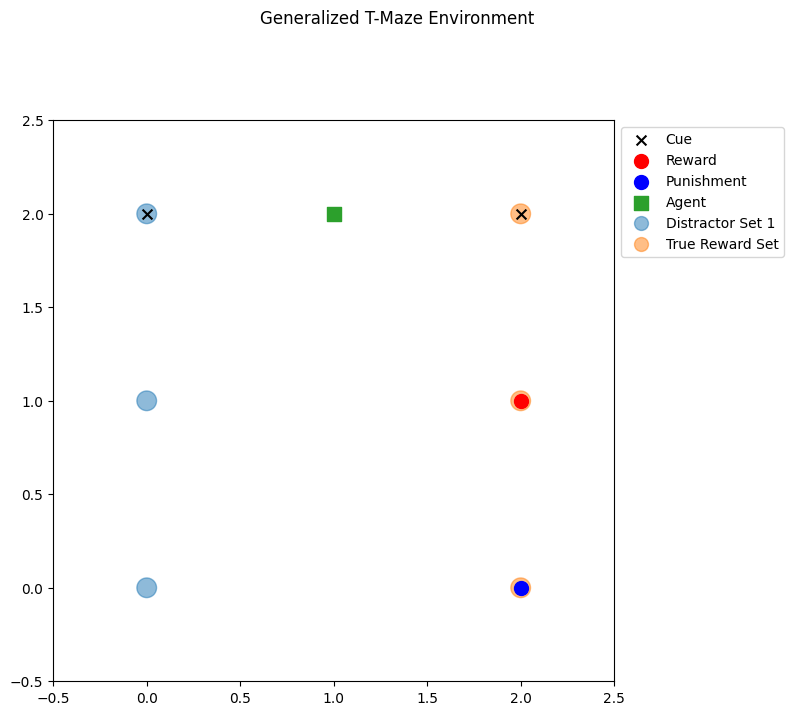

In [2]:
key, subkey = jr.split(key)
M = get_maze_matrix(small=True)
env_info = parse_maze(M, subkey)
tmaze_env = GeneralizedTMazeEnv(env_info)

init_obs, init_state = tmaze_env.reset(key)
tmaze_env.render(states=init_state, mode="human")

In [3]:
A, B = tmaze_env.A, tmaze_env.B
A_dependencies, B_dependencies = tmaze_env.A_dependencies, tmaze_env.B_dependencies

# [position], [cue], [reward]
C = list_array_zeros([a.shape[0] for a in A])

rewarding_modality = 2 + env_info["num_cues"]

C[rewarding_modality] = C[rewarding_modality].at[1].set(2.0)
C[rewarding_modality] = C[rewarding_modality].at[2].set(-3.0)

D = list_array_uniform([b.shape[0] for b in B])
D[0] = tmaze_env.D[0].copy()

agent = Agent(
    A, B, C, D, 
    None, None, None, 
    policy_len=1,
    A_dependencies=A_dependencies, 
    B_dependencies=B_dependencies
    )

In [4]:
qs = agent.infer_states(
    observations=jtu.tree_map(lambda x: jnp.broadcast_to(x, (agent.batch_size,) + x.shape), init_obs),
    past_actions=None,
    empirical_prior=agent.D,
    qs_hist=None,
)

In [5]:
from pymdp.planning.si import si_policy_search

key = jr.PRNGKey(0)
policy_search = si_policy_search(horizon=3, entropy_stop_threshold=0.0, gamma=5)
qpi, info = policy_search(agent, qs, key) 


When plotting the plan tree, the preferred plan is indeed to go to the right cue, and then fetch the reward.

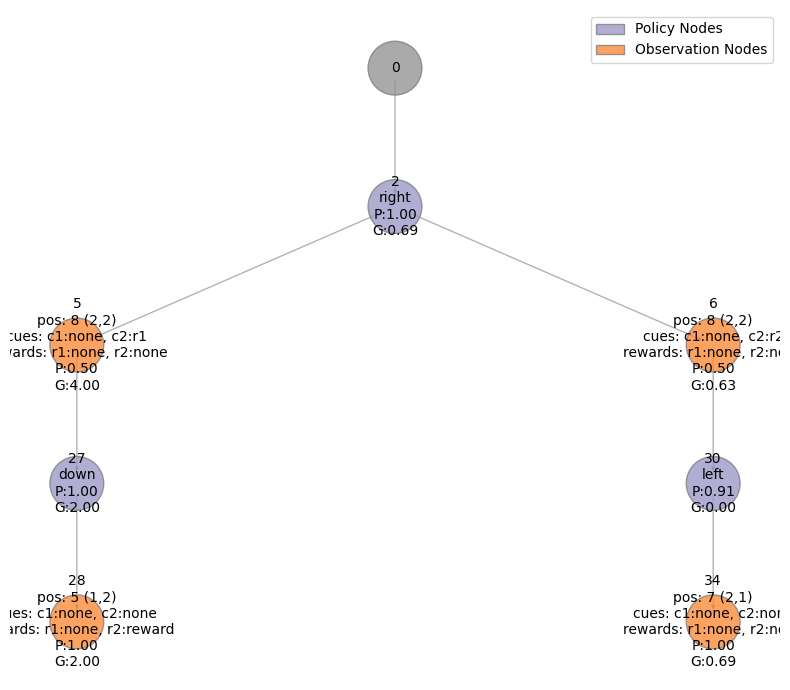

In [7]:
from pymdp.planning.visualize import visualize_plan_tree


def generalized_tmaze_observation_description(observation, model=None, env_info=env_info):
    obs = observation[0]
    maze_shape = env_info["maze"].shape
    num_cues = env_info["num_cues"]

    pos_idx = int(obs[0])
    row, col = divmod(pos_idx, maze_shape[1])

    cue_vals = [int(v) for v in obs[1 : 1 + num_cues]]
    reward_vals = [int(v) for v in obs[1 + num_cues : 1 + (2 * num_cues)]]

    cue_map = {0: "none", 1: "r1", 2: "r2"}
    reward_map = {0: "none", 1: "reward", 2: "punish"}

    cues_str = ", ".join(
        f"c{i + 1}:{cue_map.get(v, v)}" for i, v in enumerate(cue_vals)
    )
    rewards_str = ", ".join(
        f"r{i + 1}:{reward_map.get(v, v)}" for i, v in enumerate(reward_vals)
    )

    return (
        f"pos: {pos_idx} ({row},{col})\n"
        f"cues: {cues_str}\n"
        f"rewards: {rewards_str}"
    )


def generalized_tmaze_action_description(action, model=None):
    action_idx = int(action[0])
    actions = ["down", "up", "left", "right", "stay"]

    if 0 <= action_idx < len(actions):
        return actions[action_idx]
    return str(action_idx)


visualize_plan_tree(
    info,
    time_idx=None,
    observation_description=generalized_tmaze_observation_description,
    action_description=generalized_tmaze_action_description,
)


If we limit the planning horizon to a single step, we can see that indeed it renders both cues equally attractive.

In [8]:
policy_search = si_policy_search(horizon=1, entropy_stop_threshold=0.0, gamma=5)
qpi, info = policy_search(agent, qs, key) 

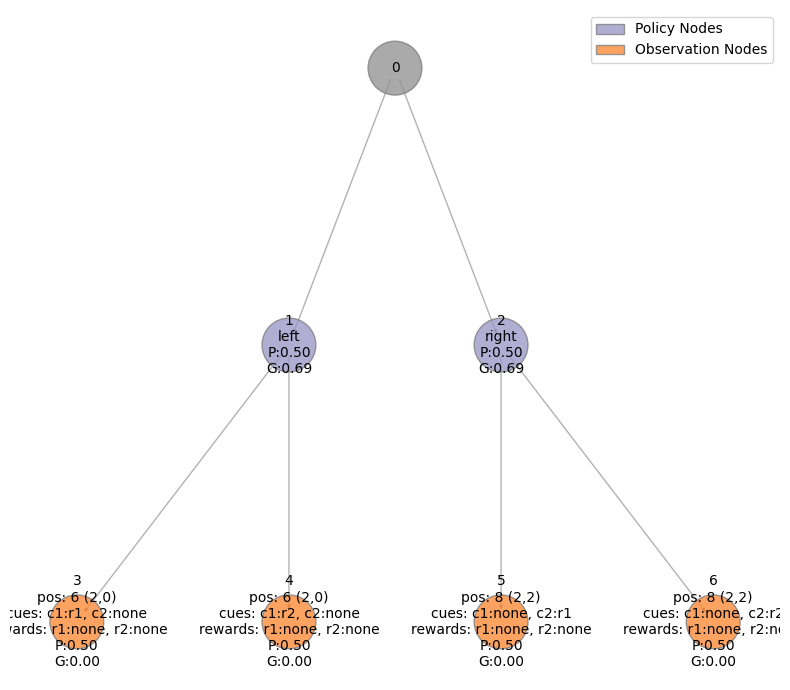

In [9]:
visualize_plan_tree(
    info,
    time_idx=None,
    observation_description=generalized_tmaze_observation_description,
    action_description=generalized_tmaze_action_description,
)
